# Подбор порога амплитуды (Чуа, manuscript_chua_2)

Амплитуда — **размах по полной RK-траектории** (без сечения Пуанкаре): после `AMPLITUDE_BURN_RK_STEPS` шагов интегрирования берём окно длиной `AMPLITUDE_RECORD_RK_STEPS` шагов и считаем $\|\mathrm{ptp}(U)\|_2$ по всем компонентам состояния $U$ (как `full_trajectory_ptp_norm` в `utils/trajectories.py`). Если за окно интегрирования норма состояния превышает порог расхождения — траектория считается разошедшейся, в гистограмму не попадает.

Траектории с **амплитудой $\ge$ порога** отбрасываем при обучении (`train_exclude_large_lc.py`). Порог переносите в `REJECT_AMPLITUDE_ABOVE` в `e2_chua_config.py` (те же `AMPLITUDE_*` и порог расхождения должны совпадать с обучением).


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "systems" / "chua_rk4.py").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Не найден корень репозитория. Запустите ноутбук с cwd в neuromap_sync или в experiments/manuscript_chua_2."
    )


_REPO = _find_repo_root(Path.cwd())
_M = _REPO / "experiments" / "manuscript_chua_2"
for _p in (_REPO, _M):
    s = str(_p)
    if s not in sys.path:
        sys.path.insert(0, s)

from e2_chua_config import (
    SEED,
    VARIABLES_RANGES,
    PARAMETERS_RANGES,
    DT,
    AMPLITUDE_BURN_RK_STEPS,
    AMPLITUDE_RECORD_RK_STEPS,
    RK_DIVERGENCE_THRESHOLD,
)
from systems.chua_rk4 import chua_rk4
from utils.trajectories import full_trajectory_ptp_norm


In [2]:
def one_sample(i):
    rg = np.random.default_rng(SEED + 1_000_003 * int(i))
    x0 = rg.uniform(
        [r[0] for r in VARIABLES_RANGES],
        [r[1] for r in VARIABLES_RANGES],
    )
    p0 = rg.uniform(
        [r[0] for r in PARAMETERS_RANGES],
        [r[1] for r in PARAMETERS_RANGES],
    )
    amp = full_trajectory_ptp_norm(
        chua_rk4,
        x0,
        p0,
        DT,
        AMPLITUDE_BURN_RK_STEPS,
        AMPLITUDE_RECORD_RK_STEPS,
        RK_DIVERGENCE_THRESHOLD,
    )
    return {"amplitude": amp, "x0": x0, "p0": p0}

Увеличьте `n_samples` и при необходимости `n_jobs`, если разделение режимов по амплитуде должно быть устойчивее.


In [3]:
n_samples = 800
n_jobs = -1

rows = Parallel(n_jobs=n_jobs, backend="loky")(delayed(one_sample)(i) for i in range(n_samples))

amps = [r["amplitude"] for r in rows]
mask_fin = np.array([a is not None for a in amps], dtype=bool)
amps_num = np.array([float(a) if a is not None else np.nan for a in amps])

print("без расхождения (конечная амплитуда):", int(mask_fin.sum()), "/", n_samples)
print("расхождений:", int((~mask_fin).sum()))

без расхождения (конечная амплитуда): 800 / 800
расхождений: 0


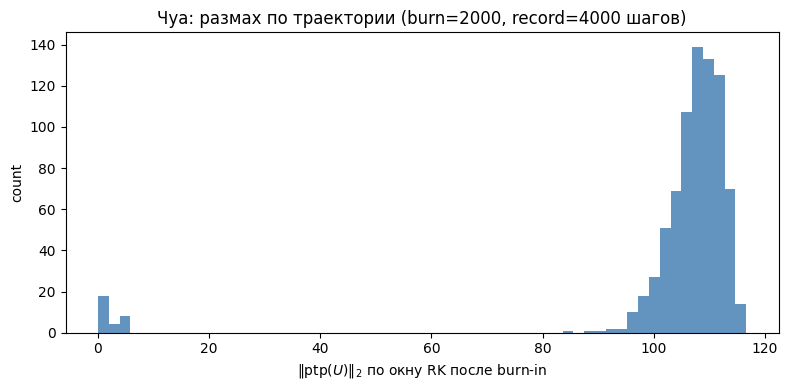

In [5]:
a = amps_num[np.isfinite(amps_num)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(a, bins=60, color="steelblue", alpha=0.85)
ax.set_xlabel(r"$\|\mathrm{ptp}(U)\|_2$ по окну RK после burn-in")
ax.set_ylabel("count")
ax.set_title(
    f"Чуа: размах по траектории (burn={AMPLITUDE_BURN_RK_STEPS}, record={AMPLITUDE_RECORD_RK_STEPS} шагов)"
)

plt.tight_layout()
plt.show()